In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator

In [3]:
file = pd.read_csv("./citrus_production.csv", delimiter=';').dropna()

In [4]:
years = np.astype(file.Rok.values, np.float64)
production = file['Produkcja [10^5 kg]'].values

In [5]:
def create_lagrange_polynomial(nodes):
    result_functions = []
    for j in range(len(nodes)):
        l_j = lambda x, j_idx=j, all_nodes=nodes: np.prod([
            (x - n) / (all_nodes[j_idx] - n)
            for k, n in enumerate(all_nodes) if k != j_idx
        ], axis=0)
        result_functions.append(l_j)
    return result_functions

In [6]:
x_est = np.array([1962, 1977, 1992])
y_true = np.array([12380, 27403, 32059])

In [7]:
cs_not_a_knot = CubicSpline(years, production, bc_type='not-a-knot')
cs_natural = CubicSpline(years, production, bc_type='natural')
cs_hermite = PchipInterpolator(years, production)

y_cs_nak = cs_not_a_knot(x_est)
y_cs_nat = cs_natural(x_est)
y_cs_herm = cs_hermite(x_est)

In [ ]:
unique_polynomials = create_lagrange_polynomial(years)
lagrange_poly = lambda x: sum(y * L(x) for y, L in zip(production, unique_polynomials))

y_lag = np.array([lagrange_poly(val) for val in x_est])

In [11]:

print("Szacowane wartości          (1962, 1977, 1992):")
print("-" * 40)
print(f"Prawdziwe wartości:        {y_true}")
print(f"Cubic Spline (not-a-knot): {np.round(y_cs_nak, 2)}")
print(f"Cubic Spline (natural):    {np.round(y_cs_nat, 2)}")
print(f"Cubic Spline Hermit:       {np.round(y_cs_herm, 2)}")
print(f"Lagrange:                  {np.round(y_lag, 2)}")

Szacowane wartości          (1962, 1977, 1992):
----------------------------------------
Prawdziwe wartości:        [12380 27403 32059]
Cubic Spline (not-a-knot): [ 5146.1  22641.77 41894.36]
Cubic Spline (natural):    [13285.3  22934.24 37798.  ]
Cubic Spline Hermit:       [13868.97 25204.28 32663.33]
Lagrange:                  [-77765.36  15404.96  43127.21]


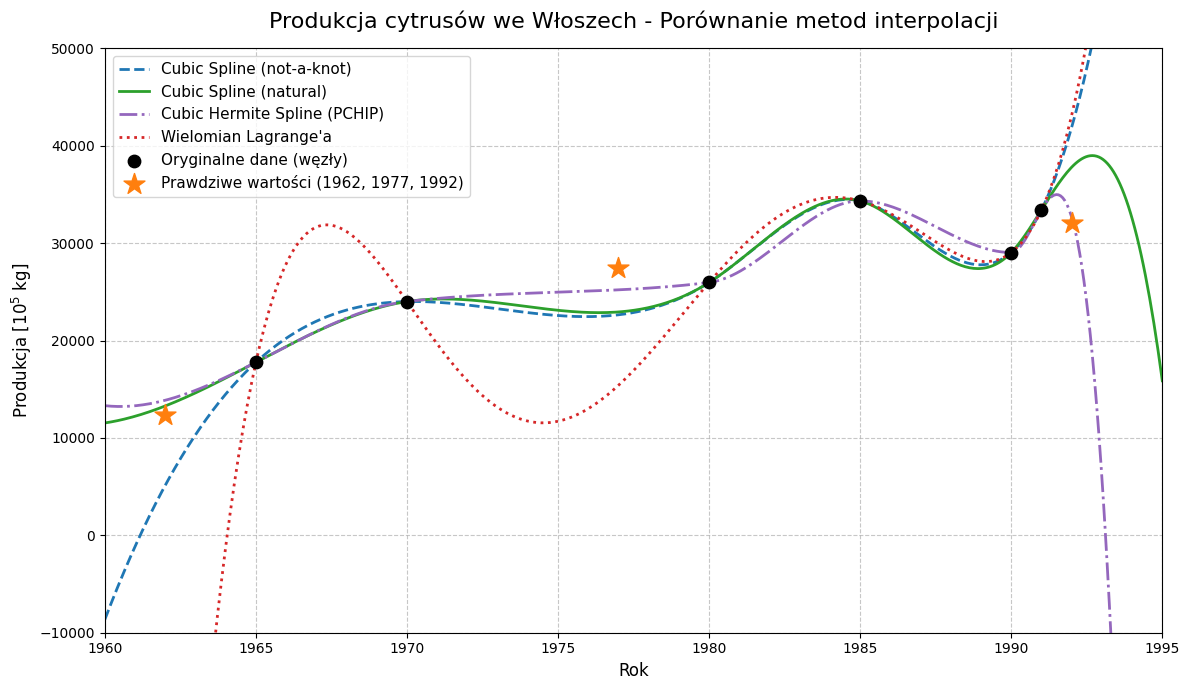

In [10]:
x_cont = np.linspace(1960, 1995, 500)

y_cs_nak_cont = cs_not_a_knot(x_cont)
y_cs_nat_cont = cs_natural(x_cont)
y_cs_herm_cont = cs_hermite(x_cont)
y_lag_cont = np.array([lagrange_poly(val) for val in x_cont])

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(x_cont, y_cs_nak_cont, label='Cubic Spline (not-a-knot)', color='#1f77b4', linewidth=2, linestyle='--')
ax.plot(x_cont, y_cs_nat_cont, label='Cubic Spline (natural)', color='#2ca02c', linewidth=2)
ax.plot(x_cont, y_cs_herm_cont, label='Cubic Hermite Spline (PCHIP)', color='#9467bd', linewidth=2, linestyle='-.')
ax.plot(x_cont, y_lag_cont, label='Wielomian Lagrange\'a', color='#d62728', linewidth=2, linestyle=':')

ax.scatter(years, production, color='black', s=80, zorder=5, label='Oryginalne dane (węzły)')
ax.scatter(x_est, y_true, color='#ff7f0e', marker='*', s=250, zorder=6, label='Prawdziwe wartości (1962, 1977, 1992)')

ax.set_title('Produkcja cytrusów we Włoszech - Porównanie metod interpolacji', fontsize=16, pad=15)
ax.set_xlabel('Rok', fontsize=12)
ax.set_ylabel('Produkcja [$10^5$ kg]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=11, loc='upper left')

ax.set_ylim(-10000, 50000)
ax.set_xlim(1960, 1995)

plt.tight_layout()